# Классификация пассажиров автобуса (входящие / выходящие) — fine-tuning EfficientNetB0

**Цель:** добиться точности работы модели выше 90% на проверочной выборке.

**Подход:** вместо обучения свёрточной сети с нуля используется **fine-tuning** предобученной модели **EfficientNetB0** из `tf.keras.applications`. Эта модель обучена на ImageNet и уже умеет извлекать общие визуальные признаки — нам остаётся только адаптировать её под бинарную классификацию пассажиров.

**Стратегия (двухэтапная):**
1. *Этап 1.* Вся база EfficientNetB0 заморожена, обучается только новая голова.
2. *Этап 2.* Размораживаются верхние блоки (`block6` и `block7`), донастройка с очень маленьким `lr`.

**Отличие от классической CNN:** EfficientNet использует **свой собственный `preprocess_input`** (нормализация в `[-1, 1]`), поэтому из аугментации убран `rescale=1./255` — иначе данные нормализовались бы дважды и качество просело.


## Загрузка данных

In [ ]:
# загрузка библиотек

# Методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# Для работы с файлами
import os

# Импортируем модуль для загрузки данных
import gdown

# Для разделения выборок
from sklearn.model_selection import train_test_split

# Для автоматического расчёта весов классов
from sklearn.utils.class_weight import compute_class_weight

# Матрица ошибок и отчёт классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Генератор аугментированных изображений
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Для создания сети — теперь Model API (functional), а не Sequential
from tensorflow.keras.models import Model

# Для создания слоёв (для головы модели)
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D)

# Предобученная модель EfficientNetB0 + её собственный preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Для работы с изображениями
from tensorflow.keras.preprocessing import image

# Колбеки
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Преобразование меток в One-Hot
from tensorflow.keras.utils import to_categorical

# Оптимизатор
from tensorflow.keras.optimizers import Adam


In [ ]:
# Загрузка датасета (.zip-архив)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip', None, quiet=True)

# Распаковка архива
!unzip -q "bus.zip" -d /content/bus

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = '/content/bus'
os.listdir(IMAGE_PATH)

['Входящий', 'Выходящий']

In [ ]:
# Определение списка имён классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 2, метки классов: ['Входящий', 'Выходящий']


## Гиперпараметры

In [ ]:
# Параметры разделения выборок
TEST_SPLIT          = 0.1                   # Доля тестовых данных в общем наборе
VAL_SPLIT           = 0.2                   # Доля проверочной выборки в обучающем наборе

# Параметры изображения
# Соотношение 1:2 (фигура человека) сохраняем, но размер увеличен:
# EfficientNetB0 училась на ImageNet (224x224), и слишком маленькие картинки
# не дают раскрыть её потенциал. 96x192 — компромисс между качеством и скоростью.
IMG_WIDTH           = 96                    # Ширина изображения для нейросети
IMG_HEIGHT          = 192                   # Высота изображения для нейросети
IMG_CHANNELS        = 3                     # RGB

# Параметры аугментации
ROTATION_RANGE      = 15                    # Пределы поворота в градусах
WIDTH_SHIFT_RANGE   = 0.1                   # Пределы сдвига по горизонтали
HEIGHT_SHIFT_RANGE  = 0.1                   # Пределы сдвига по вертикали
ZOOM_RANGE          = 0.1                   # Пределы увеличения/уменьшения
BRIGHTNESS_RANGE    = (0.7, 1.3)            # Пределы изменения яркости
HORIZONTAL_FLIP     = False                 # Без флипа: направление движения важно

# Параметры обучения
EPOCHS_STAGE1       = 10                    # Этап 1: только голова
EPOCHS_STAGE2       = 30                    # Этап 2: fine-tuning (EarlyStopping остановит раньше)
BATCH_SIZE          = 32                    # Размер батча
LR_STAGE1           = 1e-3                  # Шаг для головы
LR_STAGE2           = 1e-5                  # Очень маленький шаг для fine-tuning


## Загрузка изображений

In [ ]:
images = []
labels = []

for i, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(IMAGE_PATH, class_name)
    for img_name in os.listdir(class_path):
        img = image.load_img(os.path.join(class_path, img_name),
                             target_size=(IMG_HEIGHT, IMG_WIDTH))
        images.append(image.img_to_array(img))
        labels.append(i)

images = np.array(images, dtype='float32')
labels = np.array(labels)

print(f'Всего изображений: {len(images)}')
print(f'Форма массива: {images.shape}')
print(f'Распределение классов: {np.bincount(labels)}')

Всего изображений: 9081
Форма массива: (9081, 192, 96, 3)
Распределение классов: [6485 2596]


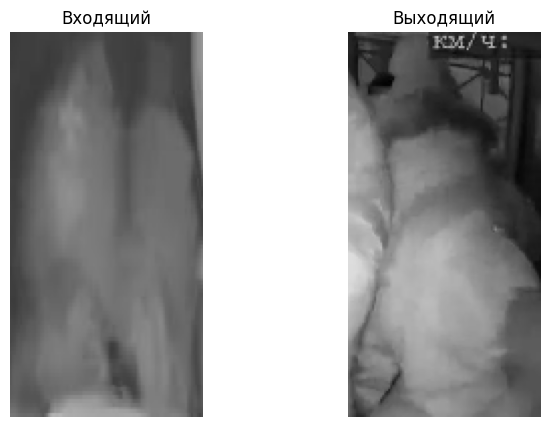

In [ ]:
# Просмотр по одному изображению из каждого класса
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(8, 5))
for i in range(CLASS_COUNT):
    idx = np.where(labels == i)[0][0]
    axs[i].imshow(images[idx].astype('uint8'))
    axs[i].set_title(CLASS_LIST[i])
    axs[i].axis('off')
plt.show()

## Разделение на train / val / test со стратификацией

In [ ]:
# Сначала отделяем тестовую выборку (10% от всех данных)
x_train_full, x_test, y_train_full, y_test = train_test_split(
    images, labels,
    test_size=TEST_SPLIT,
    random_state=42,
    stratify=labels
)

# Затем делим оставшиеся данные на обучающую и проверочную (20% от обучающего набора)
x_train, x_val, y_train_raw, y_val_raw = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT,
    random_state=42,
    stratify=y_train_full
)

# Преобразуем метки в One-Hot Encoding
y_train = to_categorical(y_train_raw, num_classes=CLASS_COUNT)
y_val = to_categorical(y_val_raw, num_classes=CLASS_COUNT)
y_test_ohe = to_categorical(y_test, num_classes=CLASS_COUNT)

print(f'Обучающий набор:    {x_train.shape}, метки: {y_train.shape}')
print(f'Проверочный набор:  {x_val.shape}, метки: {y_val.shape}')
print(f'Тестовый набор:     {x_test.shape}, метки: {y_test_ohe.shape}')

Обучающий набор:    (6537, 192, 96, 3), метки: (6537, 2)
Проверочный набор:  (1635, 192, 96, 3), метки: (1635, 2)
Тестовый набор:     (909, 192, 96, 3), метки: (909, 2)


In [ ]:
# Проверка распределения классов в каждой выборке
def print_balance(y_data, set_name):
    if len(y_data.shape) > 1:
        y_data = np.argmax(y_data, axis=1)
    unique, counts = np.unique(y_data, return_counts=True)
    print(f'Распределение в {set_name}:')
    for i, count in enumerate(counts):
        print(f'  Класс {CLASS_LIST[i]}: {count} ({count/len(y_data)*100:.1f}%)')

print_balance(y_train, 'обучающем наборе')
print_balance(y_val, 'проверочном наборе')
print_balance(y_test_ohe, 'тестовом наборе')

Распределение в обучающем наборе:
  Класс Входящий: 4668 (71.4%)
  Класс Выходящий: 1869 (28.6%)
Распределение в проверочном наборе:
  Класс Входящий: 1168 (71.4%)
  Класс Выходящий: 467 (28.6%)
Распределение в тестовом наборе:
  Класс Входящий: 649 (71.4%)
  Класс Выходящий: 260 (28.6%)


In [ ]:
# Автоматический расчёт весов классов для компенсации дисбаланса
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Веса классов: {class_weight_dict}')

Веса классов: {0: np.float64(0.7001928020565553), 1: np.float64(1.7487961476725522)}


## Аугментация изображений

In [ ]:
# ВАЖНО: для EfficientNet НЕ используем rescale=1./255.
# Вместо этого передаём её собственную функцию preprocess_input через preprocessing_function.
# Эта функция сама приведёт значения пикселей к нужному диапазону ([-1, 1]).
# Если оставить rescale=1./255, данные нормализовались бы дважды — качество просело бы.

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,    # вместо rescale
    rotation_range=ROTATION_RANGE,
    width_shift_range=WIDTH_SHIFT_RANGE,
    height_shift_range=HEIGHT_SHIFT_RANGE,
    zoom_range=ZOOM_RANGE,
    brightness_range=BRIGHTNESS_RANGE,
    horizontal_flip=HORIZONTAL_FLIP,
)

# Для проверочной и тестовой выборок — только preprocess_input (без аугментации)
val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Создание генераторов
train_generator      = train_datagen.flow(x_train, y_train,     batch_size=BATCH_SIZE, shuffle=True)
validation_generator = val_datagen.flow(x_val,   y_val,         batch_size=BATCH_SIZE, shuffle=False)
test_generator       = test_datagen.flow(x_test, y_test_ohe,    batch_size=BATCH_SIZE, shuffle=False)


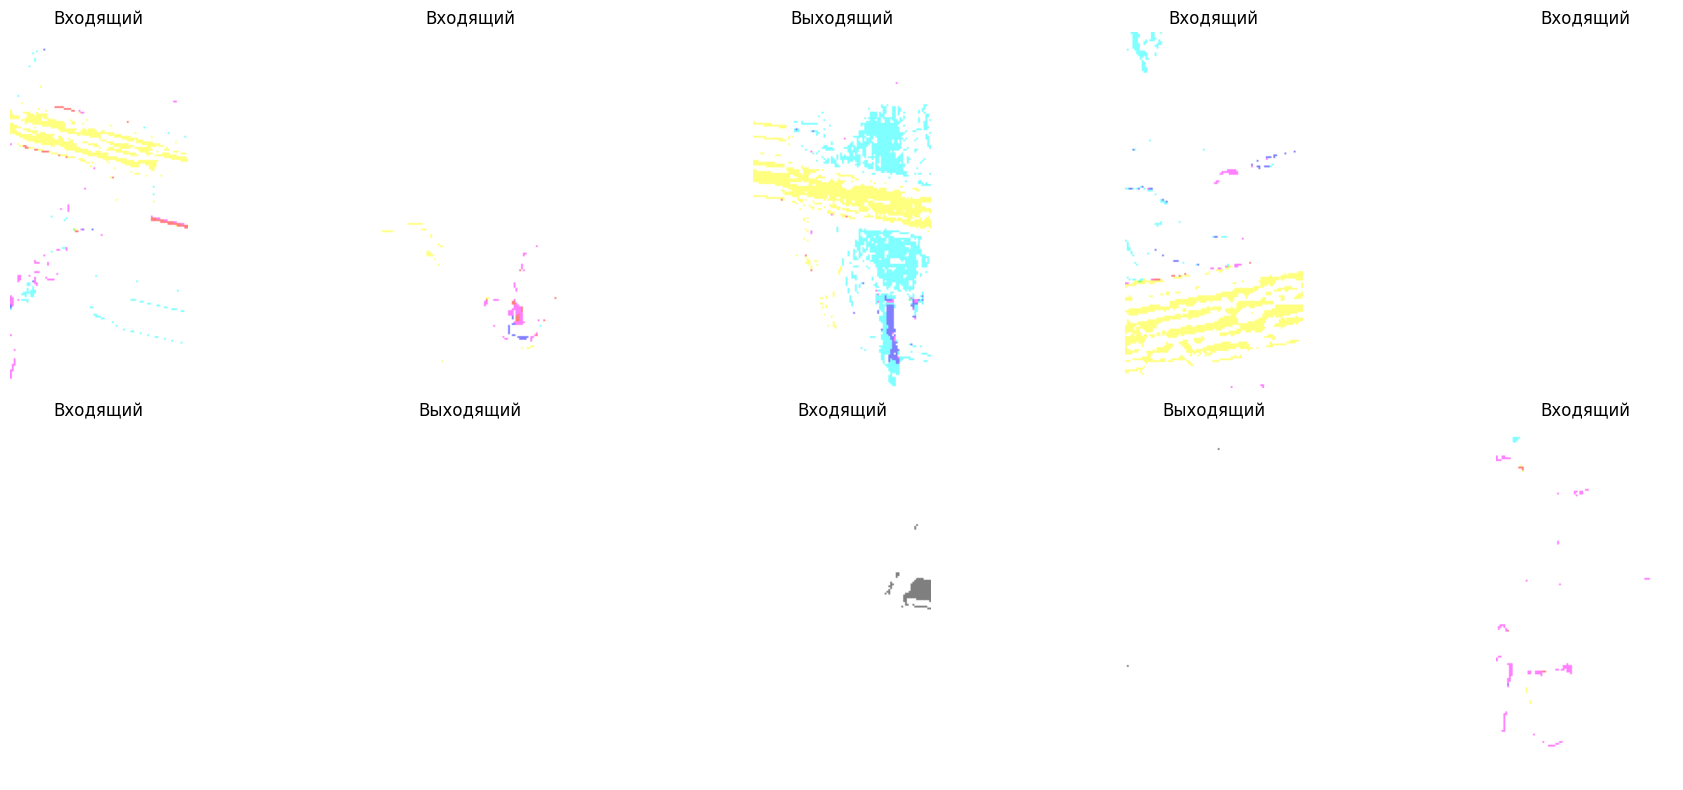

In [ ]:
# Проверка работы аугментации.
# Данные после preprocess_input лежат в [-1, 1], для отображения возвращаем в [0, 1].
def show_batch(batch, img_range=range(10), figsize=(20, 8), columns=5):
    num_images = len(img_range)
    rows = (num_images + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = axes.flatten()
    for i, img_idx in enumerate(img_range):
        img = batch[0][img_idx]
        # обратное преобразование для отображения: [-1, 1] -> [0, 1]
        img_show = np.clip((img + 1.0) / 2.0, 0, 1)
        axes[i].imshow(img_show)
        class_label_idx = np.argmax(batch[1][img_idx])
        axes[i].set_title(CLASS_LIST[class_label_idx])
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

example_batch = next(train_generator)
show_batch(example_batch, img_range=range(10))


## Создание модели: fine-tuning EfficientNetB0

Загружаем предобученную EfficientNetB0 без её родного классификатора (`include_top=False`) и приставляем сверху свою голову под 2 класса.

На первом этапе вся база заморожена — обучается только голова.


In [ ]:
# Загружаем предобученную EfficientNetB0
# include_top=False — без её родного классификатора на 1000 классов ImageNet
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
)

#  ЭТАП 1: замораживаем всю базу
base_model.trainable = False

#  Собираем модель через Functional API
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

# training=False важно для замороженной базы:
# слои BatchNorm (а в EfficientNet их много) останутся в режиме inference
# и не будут обновлять свою статистику.
x = base_model(inputs, training=False)

# Голова модели
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(CLASS_COUNT, activation='softmax')(x)

cnn_model = Model(inputs, outputs)
cnn_model.summary()

# Подсчёт параметров
trainable     = sum([np.prod(v.shape) for v in cnn_model.trainable_weights])
non_trainable = sum([np.prod(v.shape) for v in cnn_model.non_trainable_weights])
print(f'\nОбучаемых параметров (этап 1):     {trainable:,}')
print(f'Замороженных параметров (этап 1):   {non_trainable:,}')


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 192, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 6, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,917 (16.09 MB)

 Trainable params: 166,786 (651.51 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


Обучаемых параметров (этап 1):     166,786
Замороженных параметров (этап 1):   4,052,131.0


## Обучение модели (двухэтапное)

На первом этапе быстро адаптируем голову. Затем размораживаем верхушку EfficientNetB0 (`block6` и `block7` — самые глубокие, отвечают за высокоуровневые признаки) и продолжаем обучение с очень маленьким `lr=1e-5`. Очень маленький шаг важен, чтобы не «сломать» уже хорошо настроенные веса базы.

Колбэки `EarlyStopping` и `ReduceLROnPlateau` остановят обучение, если перестанем улучшаться на проверочной выборке.


In [ ]:
# Колбэки
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1,
)

#  ЭТАП 1: обучение головы (база заморожена)
cnn_model.compile(
    optimizer=Adam(learning_rate=LR_STAGE1),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


print('ЭТАП 1: обучение головы (база EfficientNetB0 заморожена)')
history1 = cnn_model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reducer],
    verbose=1,
)

#  ЭТАП 2: размораживаем block6 и block7
# Сначала размораживаем всю базу...
base_model.trainable = True

# ...а потом замораживаем обратно всё, КРОМЕ block6 и block7.
# Дополнительно: BatchNorm-слои оставляем в режиме inference (frozen) —
# это стандартная практика для fine-tuning EfficientNet, иначе статистика BN
# может «съехать» на маленьком батче и испортить предсказания.
for layer in base_model.layers:
    if not (layer.name.startswith('block6') or layer.name.startswith('block7')):
        layer.trainable = False
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# Перекомпилируем с очень маленьким lr
cnn_model.compile(
    optimizer=Adam(learning_rate=LR_STAGE2),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

trainable = sum([np.prod(v.shape) for v in cnn_model.trainable_weights])
print(f'\nОбучаемых параметров (этап 2): {trainable:,}')

# Сбрасываем early_stop, чтобы patience считался заново для второго этапа
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=7,
    restore_best_weights=True, verbose=1,
)
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3,
    min_lr=1e-7, verbose=1,
)

print()
print(f'ЭТАП 2: fine-tuning block6+block7 (lr = {LR_STAGE2})')
history2 = cnn_model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=validation_generator,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_reducer],
    verbose=1,
)

# Склеиваем истории двух этапов в одну
history = type('H', (), {})()  # пустой объект, чтобы дальше использовать history.history как раньше
history.history = {
    'accuracy':     history1.history['accuracy']     + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss':         history1.history['loss']         + history2.history['loss'],
    'val_loss':     history1.history['val_loss']     + history2.history['val_loss'],
}

# Запоминаем границу для графика
STAGE_BOUNDARY = len(history1.history['accuracy']) - 0.5


ЭТАП 1: обучение головы (база EfficientNetB0 заморожена)
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 105s 358ms/step - accuracy: 0.8161 - loss: 0.4335 - val_accuracy: 0.9413 - val_loss: 0.1698 - learning_rate: 0.0010
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - accuracy: 0.8828 - loss: 0.2681 - val_accuracy: 0.9523 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 202ms/step - accuracy: 0.9082 - loss: 0.2048 - val_accuracy: 0.9590 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 173ms/step - accuracy: 0.9151 - loss: 0.2033 - val_accuracy: 0.9682 - val_loss: 0.0820 - learning_rate: 0.0010
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 175ms/step - accuracy: 0.9301 - loss: 0.1608 - val_accuracy: 0.9676 - val_loss: 0.0875 - learning_rate: 0.0010
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 36s 176ms/step - accuracy: 0.9393 - loss: 0.1455 - val_accuracy: 0.9657 - val_loss: 0.0827 - learning_rate: 0.0010
Epoch 7/10
2

## График обучения

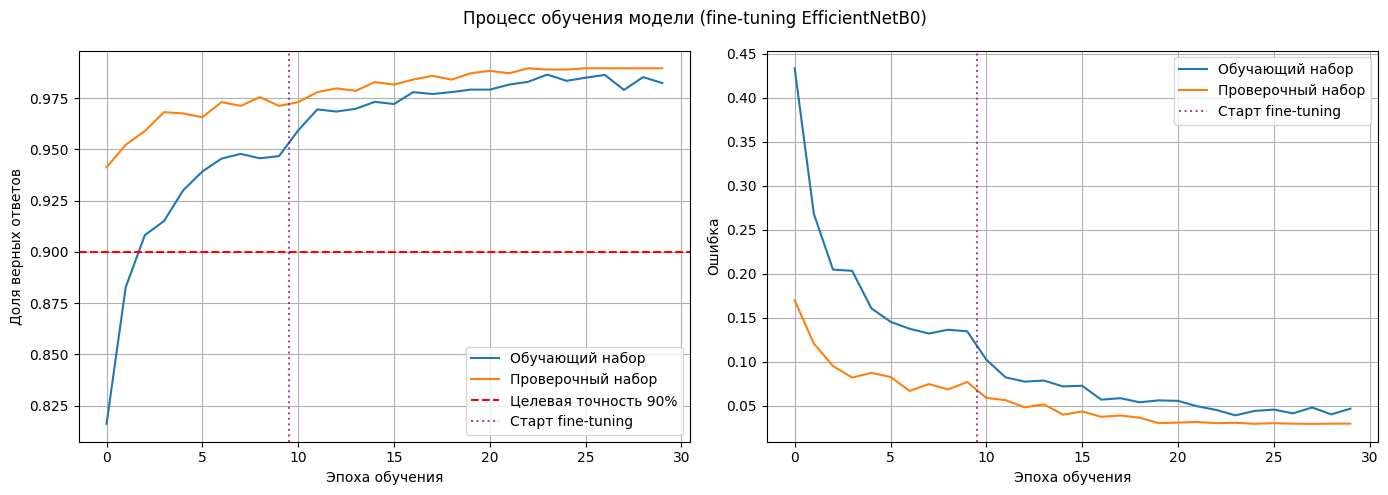

Лучшая точность на проверочной выборке: 98.96%
Целевая точность 90% ДОСТИГНУТА


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Процесс обучения модели (fine-tuning EfficientNetB0)')

ax1.plot(history.history['accuracy'],     label='Обучающий набор')
ax1.plot(history.history['val_accuracy'], label='Проверочный набор')
ax1.axhline(y=0.9, color='r', linestyle='--', label='Целевая точность 90%')
ax1.axvline(x=STAGE_BOUNDARY, color='purple', linestyle=':', alpha=0.7, label='Старт fine-tuning')
ax1.set_xlabel('Эпоха обучения')
ax1.set_ylabel('Доля верных ответов')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Обучающий набор')
ax2.plot(history.history['val_loss'], label='Проверочный набор')
ax2.axvline(x=STAGE_BOUNDARY, color='purple', linestyle=':', alpha=0.7, label='Старт fine-tuning')
ax2.set_xlabel('Эпоха обучения')
ax2.set_ylabel('Ошибка')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'Лучшая точность на проверочной выборке: {best_val_acc*100:.2f}%')
print(f'Целевая точность 90% {"ДОСТИГНУТА" if best_val_acc >= 0.9 else "НЕ достигнута"}')


## Оценка на тестовой выборке

29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 491ms/step


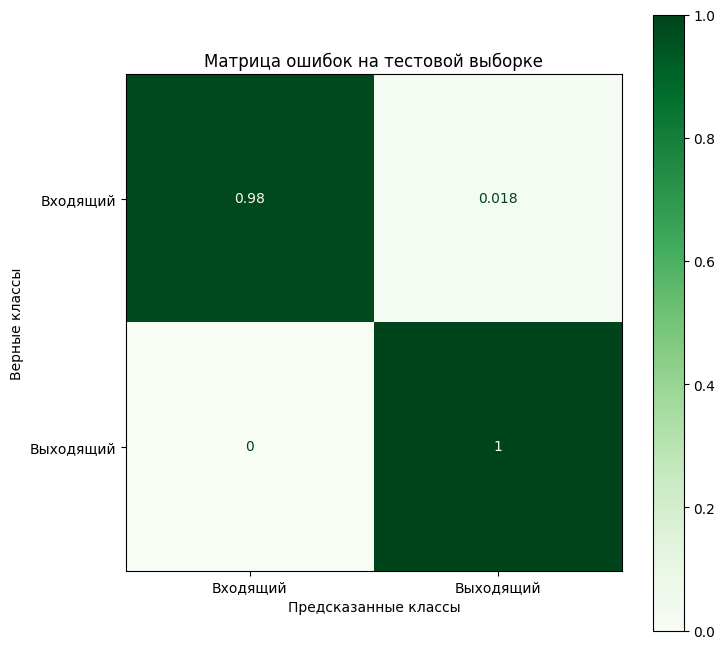


Подробный отчёт по классам:
              precision    recall  f1-score   support

    Входящий       1.00      0.98      0.99       649
   Выходящий       0.96      1.00      0.98       260

    accuracy                           0.99       909
   macro avg       0.98      0.99      0.98       909
weighted avg       0.99      0.99      0.99       909



In [ ]:
# Получаем предсказания на ВСЕЙ тестовой выборке (а не на одном батче)
test_generator.reset()
y_pred = cnn_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test  # исходные метки до OHE

# Матрица ошибок (нормализованная по строкам)
cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
cm = np.round(cm, 3)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax, cmap='Greens', colorbar=True)
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанные классы')
plt.ylabel('Верные классы')
plt.show()

# Подробный отчёт: precision, recall, F1 по каждому классу
print('\nПодробный отчёт по классам:')
print(classification_report(y_true, y_pred_classes, target_names=CLASS_LIST))

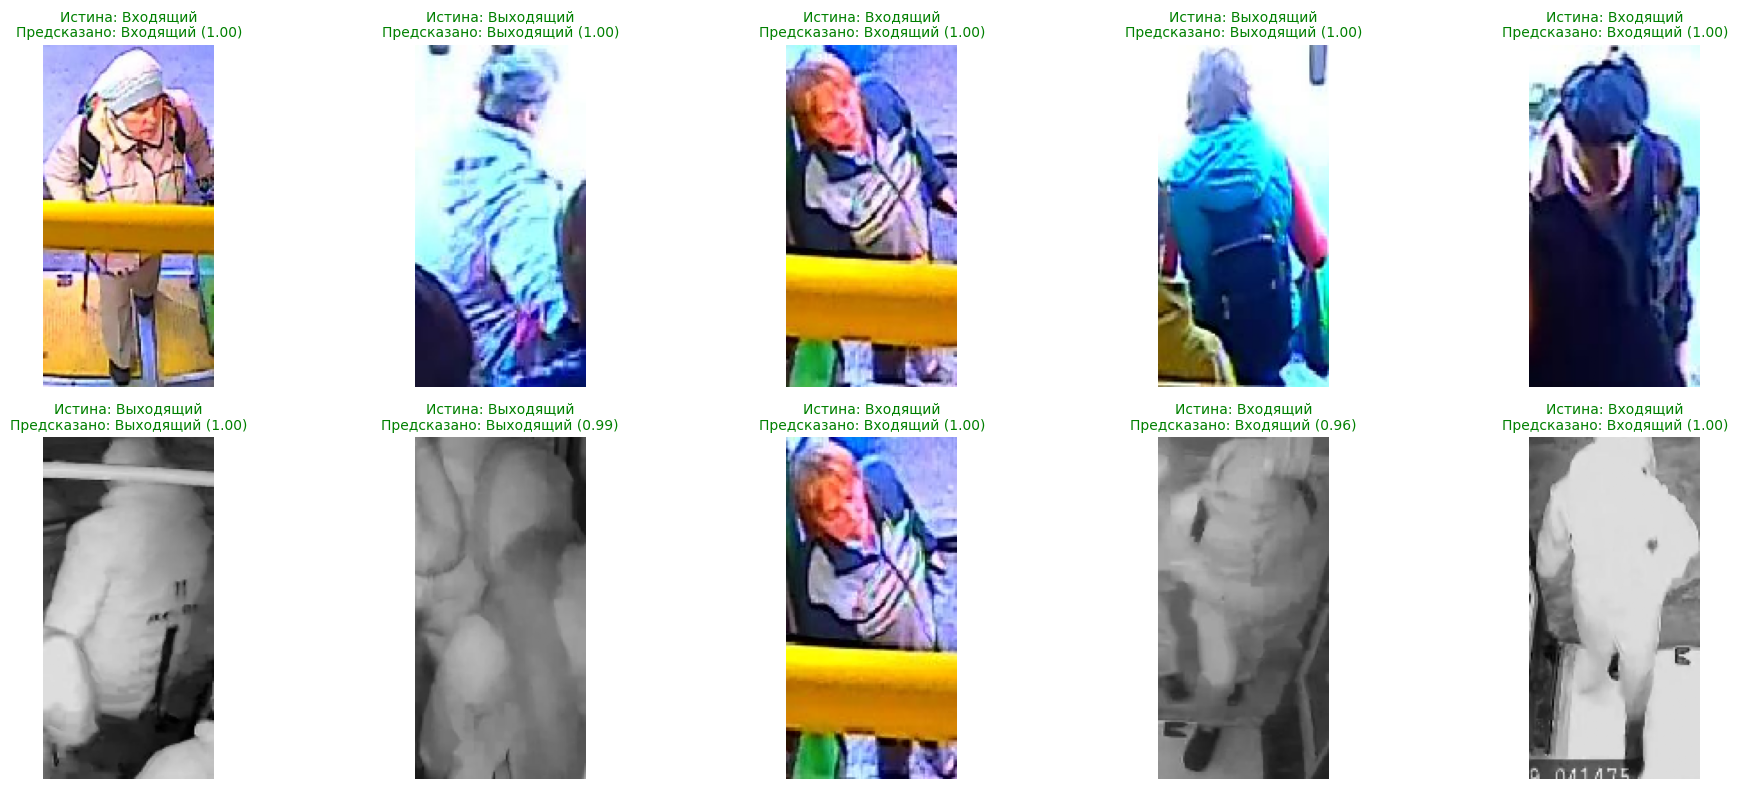

In [ ]:
# Визуальный просмотр предсказаний на случайных примерах.
# x_test ещё в исходном виде (0..255), preprocess_input применяется в test_generator.
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

indices = random.sample(range(len(x_test)), 10)
for i, idx in enumerate(indices):
    img = (x_test[idx] / 255.0).clip(0, 1)
    true_label = CLASS_LIST[y_test[idx]]
    pred_label = CLASS_LIST[y_pred_classes[idx]]
    pred_proba = y_pred[idx][y_pred_classes[idx]]

    color = 'green' if true_label == pred_label else 'red'
    axs[i].imshow(img)
    axs[i].set_title(f'Истина: {true_label}\nПредсказано: {pred_label} ({pred_proba:.2f})',
                     color=color, fontsize=10)
    axs[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Сохранение модели
cnn_model.save('efficientnet_pro_finetuned.keras')
print('Модель сохранена в efficientnet_pro_finetuned.keras')


Модель сохранена в efficientnet_pro_finetuned.keras
